# 模块 06：多层网络

## 1. 理论背景
MLP 将多个全连接层与非线性激活堆叠起来。本模块用二维合成数据演示一个小型分类网络，结构与 MNIST 分类的 `784 -> 128 -> 64 -> 10` 思路一致。

## 1.1 实际作用（用途）
- 适合表格数据和固定长度特征的分类/回归任务，例如信用评分、价格预测或用户流失预测。
- 常作为其他模型中的子模块，例如 Transformer 的 FeedForward 层。
- 可作为快速原型和基线，验证特征是否包含足够预测信息。

## 2. 数学推导
隐藏层：$a_1=ReLU(XW_1+b_1)$。输出 logits：$z_2=a_1W_2+b_2$。Softmax 概率：$p_i=e^{z_i}/\sum_j e^{z_j}$。

交叉熵损失：$L=-\frac{1}{n}\sum_i\log p_{i,y_i}$。对 logits 的梯度是 $(p-y_{onehot})/n$。

## 3. 代码思路

本章代码实现一个完整的两层分类网络训练闭环：

1. 先构造非线性二维分类数据：两个坐标同号为一类，异号为另一类，单层线性模型难以分开。
2. 参数字典 `params` 保存两层网络的 `W1/b1/W2/b2`，便于前向和反向统一访问。
3. `mlp_forward` 执行 `Linear -> ReLU -> Linear -> Softmax`，返回分类概率和反向传播需要的缓存。
4. `train` 中用交叉熵计算损失，再利用 `softmax + cross entropy` 的简化梯度反向更新所有参数。
5. 训练后计算准确率，并用散点图展示模型学到的非线性分类边界。

## 4. NumPy 实现

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

# 构造二维二分类数据：x0 和 x1 同号为一类，异号为另一类，线性模型难以直接分开。
rng = np.random.default_rng(7)
n = 180
X = rng.normal(size=(n, 2))
y = ((X[:,0] * X[:,1] > 0)).astype(int)
Y = np.eye(2)[y]
# 两层 MLP：2 维输入 -> 12 个隐藏单元 -> 2 类 logits。
params = {'W1': rng.normal(scale=0.4, size=(2, 12)), 'b1': np.zeros(12), 'W2': rng.normal(scale=0.4, size=(12, 2)), 'b2': np.zeros(2)}

def softmax(z):
    # 减去每行最大值，避免 exp 溢出；不改变 softmax 结果。
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def mlp_forward(params, X):
    # 隐藏层用 ReLU 引入非线性，输出层产生每个类别的 logits。
    z1 = X @ params['W1'] + params['b1']
    a1 = np.maximum(0, z1)
    logits = a1 @ params['W2'] + params['b2']
    return softmax(logits), {'z1': z1, 'a1': a1, 'logits': logits}

def train(params, steps=1200, lr=0.15):
    history = []
    for _ in range(steps):
        p, c = mlp_forward(params, X)
        # 交叉熵只取真实类别对应的预测概率。
        loss = -np.mean(np.log(p[np.arange(n), y] + 1e-12))
        # softmax + cross entropy 的梯度可简化为 (p - one_hot) / n。
        dz2 = (p - Y) / n
        grads = {'W2': c['a1'].T @ dz2, 'b2': dz2.sum(axis=0)}
        da1 = dz2 @ params['W2'].T
        dz1 = da1 * (c['z1'] > 0)
        grads['W1'] = X.T @ dz1; grads['b1'] = dz1.sum(axis=0)
        # 用同一个学习率更新所有参数。
        for k in params: params[k] -= lr * grads[k]
        history.append(loss)
    return np.array(history)

loss_history = train(params)
probs, cache = mlp_forward(params, X)
acc = (probs.argmax(axis=1) == y).mean()
print('训练结果：MLP 分类准确率 =', acc, '，最终交叉熵损失 =', loss_history[-1], '；准确率越高、损失越低表示分类边界学得越好。')


训练结果：MLP 分类准确率 = 0.9888888888888889 ，最终交叉熵损失 = 0.08622560509434246 ；准确率越高、损失越低表示分类边界学得越好。


## 5. 结果验证

In [2]:
# 训练后的模型应当能拟合这个非线性二分类数据。
assert acc > 0.9
try:
    import torch
    # 只取前 16 个样本做前向对照，避免不必要的大量输出。
    Xt = torch.tensor(X[:16], dtype=torch.float64)
    W1 = torch.tensor(params['W1'], dtype=torch.float64, requires_grad=True)
    b1 = torch.tensor(params['b1'], dtype=torch.float64, requires_grad=True)
    W2 = torch.tensor(params['W2'], dtype=torch.float64, requires_grad=True)
    b2 = torch.tensor(params['b2'], dtype=torch.float64, requires_grad=True)
    logits = torch.relu(Xt @ W1 + b1) @ W2 + b2
    torch_probs = torch.softmax(logits, dim=1).detach().numpy()
    np_probs, _ = mlp_forward(params, X[:16])
    assert np.allclose(torch_probs, np_probs, atol=1e-5)
    print('验证通过：NumPy 前向计算与 PyTorch 前向计算结果一致。')
except ImportError:
    print('提示：当前环境未安装 PyTorch；MLP 训练准确率检查已通过。')


验证通过：NumPy 前向计算与 PyTorch 前向计算结果一致。


## 6. 可视化

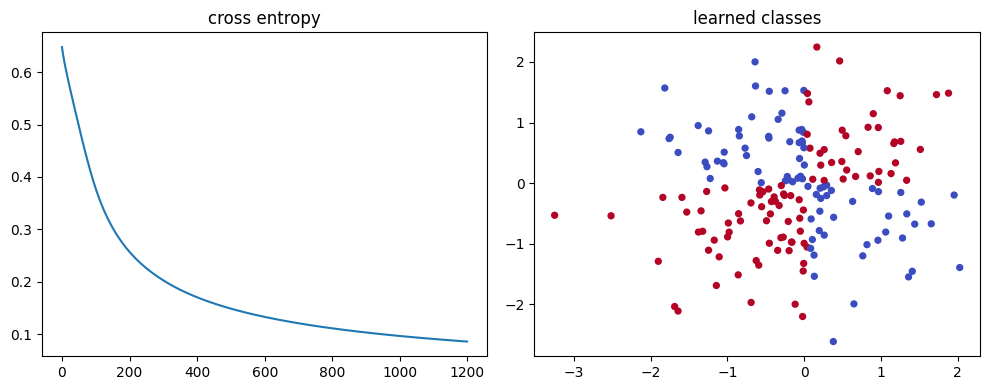

In [3]:
plt.figure(figsize=(10, 4))
# 左图看损失下降趋势，右图看训练后的分类结果。
plt.subplot(1, 2, 1); plt.plot(loss_history); plt.title('cross entropy')
plt.subplot(1, 2, 2)
plt.scatter(X[:,0], X[:,1], c=probs.argmax(axis=1), cmap='coolwarm', s=18)
plt.title('learned classes')
plt.tight_layout(); plt.show()
